In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [2]:
BASE_PATH = Path("./onti-students-performance")
X_TRAIN_PATH = BASE_PATH / "X_train.csv"
X_TEST_PATH = BASE_PATH / "X_test.csv"
Y_TRAIN_PATH = BASE_PATH / "y_train.csv"
STUDS_INFO_PATH = BASE_PATH / "studs_info.csv"
SAMPLE_SUB_PATH = BASE_PATH / "sample_submission.csv"

required_paths = [X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, STUDS_INFO_PATH, SAMPLE_SUB_PATH]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required files: " + ", ".join(missing) + ". "
        "Add the files and rerun this notebook."
    )

X_train_raw = pd.read_csv(X_TRAIN_PATH)
X_test_raw = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH)["mark"]
studs_info = pd.read_csv(STUDS_INFO_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

for frame_name, frame in [("X_train", X_train_raw), ("X_test", X_test_raw)]:
    if "Unnamed: 0" in frame.columns:
        frame.drop(columns=["Unnamed: 0"], inplace=True)

studs_info = studs_info.rename(columns={"   ": "number2", "   number": "number1"})
studs_info = studs_info.drop_duplicates(["STD_ID"]).copy()

for col in studs_info.columns:
    if studs_info[col].isna().any():
        if pd.api.types.is_numeric_dtype(studs_info[col]):
            studs_info[col] = studs_info[col].fillna(studs_info[col].mean())
        else:
            mode = studs_info[col].mode(dropna=True)
            fill_value = mode.iloc[0] if len(mode) else "unknown"
            studs_info[col] = studs_info[col].fillna(fill_value)

X_train_raw = X_train_raw.merge(studs_info, how="left", on="STD_ID")
X_test_raw = X_test_raw.merge(studs_info, how="left", on="STD_ID")

print("X_train shape:", X_train_raw.shape)
print("X_test shape:", X_test_raw.shape)
print("Target size:", y_train.shape)

X_train shape: (105058, 19)
X_test shape: (26265, 19)
Target size: (105058,)


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neural_network import MLPRegressor
from tqdm import tqdm

import math
from sklearn import preprocessing
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
import math
%matplotlib inline

In [4]:
def pick_column(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def add_calendar_features(df):
    result = df.copy()

    year_col = pick_column(result.columns, ["ГОД", "year", "Year"])
    if year_col:
        year_as_str = result[year_col].astype(str)
        result["start_year"] = pd.to_datetime(year_as_str.str[:4], errors="coerce").dt.year
        result["end_year"] = result["start_year"] + 1

    grad_col = pick_column(result.columns, ["Дата выпуска", "date_graduation", "graduation_date"])
    if grad_col:
        grad_dt = pd.to_datetime(result[grad_col], errors="coerce")
        if "end_year" not in result.columns:
            result["end_year"] = grad_dt.dt.year
        if "start_year" not in result.columns:
            result["start_year"] = grad_dt.dt.year - 1

    return result


def add_student_aggregate_features(X_train_df, X_test_df, y_series):
    train = X_train_df.copy()
    test = X_test_df.copy()

    if "STD_ID" not in train.columns:
        raise KeyError("Column 'STD_ID' is required for aggregate student features.")

    order_cols = [col for col in ["ГОД", "КУРС", "СЕМЕСТР"] if col in train.columns]
    if order_cols:
        ordered_idx = train.sort_values(order_cols).index
    else:
        ordered_idx = train.index

    tmp = pd.DataFrame(index=train.index)
    tmp["STD_ID"] = train["STD_ID"]
    tmp["mark"] = y_series.values

    tmp_ordered = tmp.loc[ordered_idx].copy()
    grouped = tmp_ordered.groupby("STD_ID", sort=False)["mark"]
    tmp_ordered["student_prev_mean_mark"] = grouped.apply(lambda s: s.shift(1).expanding().mean()).reset_index(level=0, drop=True)
    tmp_ordered["student_prev_passed_count"] = grouped.apply(lambda s: (s.shift(1) >= 3).cumsum()).reset_index(level=0, drop=True)

    tmp_agg = tmp_ordered[["student_prev_mean_mark", "student_prev_passed_count"]].reindex(train.index)

    global_mean = y_series.mean()
    tmp_agg["student_prev_mean_mark"] = tmp_agg["student_prev_mean_mark"].fillna(global_mean)
    tmp_agg["student_prev_passed_count"] = tmp_agg["student_prev_passed_count"].fillna(0)

    train["student_prev_mean_mark"] = tmp_agg["student_prev_mean_mark"]
    train["student_prev_passed_count"] = tmp_agg["student_prev_passed_count"]

    hist = pd.DataFrame({"STD_ID": train["STD_ID"], "mark": y_series.values})
    agg_map = hist.groupby("STD_ID").agg(
        student_prev_mean_mark=("mark", "mean"),
        student_prev_passed_count=("mark", lambda s: (s >= 3).sum()),
    )

    test = test.merge(agg_map, how="left", on="STD_ID")
    test["student_prev_mean_mark"] = test["student_prev_mean_mark"].fillna(global_mean)
    test["student_prev_passed_count"] = test["student_prev_passed_count"].fillna(0)

    return train, test


X_train_fe = add_calendar_features(X_train_raw)
X_test_fe = add_calendar_features(X_test_raw)
X_train_fe, X_test_fe = add_student_aggregate_features(X_train_fe, X_test_fe, y_train)

print("Feature engineered train shape:", X_train_fe.shape)
print("Feature engineered test shape:", X_test_fe.shape)

Feature engineered train shape: (105058, 23)
Feature engineered test shape: (26265, 23)


In [5]:
X_full = X_train_fe.copy()
y_full = y_train.copy()

numeric_features = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_full.columns if c not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train, X_valid, y_train_reg, y_valid_reg = train_test_split(
    X_full,
    y_full,
    test_size=0.1,
    random_state=42,
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 9
Categorical features: 14


In [6]:
reg_models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=250,
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=3,
        subsample=0.8,
        random_state=42,
    ),
}

reg_results = []
reg_fitted = {}

for name, model in reg_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    pipe.fit(X_train, y_train_reg)
    preds = pipe.predict(X_valid)
    preds = np.clip(preds, 1, 5)

    rmse = mean_squared_error(y_valid_reg, preds) ** 0.5
    mae = mean_absolute_error(y_valid_reg, preds)
    r2 = r2_score(y_valid_reg, preds)

    reg_results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})
    reg_fitted[name] = pipe

reg_results_df = pd.DataFrame(reg_results).sort_values(by="rmse")
reg_results_df

,model,rmse,mae,r2
2,GradientBoostingRegressor,0.561581,0.459735,0.447135
1,RandomForestRegressor,0.561940,0.451167,0.446427
0,LinearRegression,0.619176,0.511350,0.327916


In [7]:
y_full_cls = (y_full <= 2).astype(int)

X_train_cls, X_valid_cls, y_train_cls, y_valid_cls = train_test_split(
    X_full,
    y_full_cls,
    test_size=0.1,
    random_state=42,
    stratify=y_full_cls if y_full_cls.nunique() > 1 else None,
)

cls_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

cls_results = []
cls_fitted = {}

for name, model in cls_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    pipe.fit(X_train_cls, y_train_cls)

    pred_label = pipe.predict(X_valid_cls)
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        pred_score = pipe.predict_proba(X_valid_cls)[:, 1]
    else:
        pred_score = pipe.decision_function(X_valid_cls)

    if y_valid_cls.nunique() > 1:
        roc_auc = roc_auc_score(y_valid_cls, pred_score)
    else:
        roc_auc = np.nan

    cls_results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_valid_cls, pred_label),
            "precision": precision_score(y_valid_cls, pred_label, zero_division=0),
            "recall": recall_score(y_valid_cls, pred_label, zero_division=0),
            "f1": f1_score(y_valid_cls, pred_label, zero_division=0),
            "roc_auc": roc_auc,
        }
    )
    cls_fitted[name] = pipe

cls_results_df = pd.DataFrame(cls_results).sort_values(by="f1", ascending=False)
cls_results_df

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

In [ ]:
best_cls_name = cls_results_df.iloc[0]["model"]
best_cls_pipe = cls_fitted[best_cls_name]
best_cls_pred = best_cls_pipe.predict(X_valid_cls)

cm = confusion_matrix(y_valid_cls, best_cls_pred)
cm_df = pd.DataFrame(cm, index=["actual_ok", "actual_fail"], columns=["pred_ok", "pred_fail"])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({best_cls_name})")
plt.tight_layout()
plt.show()

cm_df

In [ ]:
def get_feature_names_from_preprocessor(prep, num_cols, cat_cols):
    return list(num_cols) + list(cat_cols)


def top_barplot(values, labels, title, top_n=20):
    imp_df = pd.DataFrame({"feature": labels, "value": values})
    imp_df["abs_value"] = imp_df["value"].abs()
    imp_df = imp_df.sort_values("abs_value", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="value", y="feature", orient="h")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp_df[["feature", "value"]]


feature_names = get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features)

for model_name in ["RandomForestClassifier", "GradientBoostingClassifier"]:
    model = cls_fitted[model_name].named_steps["model"]
    importances = model.feature_importances_
    display(top_barplot(importances, feature_names, f"Top features: {model_name}"))

lin_reg_model = reg_fitted["LinearRegression"].named_steps["model"]
lin_reg_coef = lin_reg_model.coef_
display(top_barplot(lin_reg_coef, feature_names, "Top coefficients: LinearRegression"))

In [ ]:
final_reg_name = reg_results_df.iloc[0]["model"]
final_reg_model = reg_models[final_reg_name]

final_reg_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_reg_model),
    ]
)
final_reg_pipe.fit(X_full, y_full)

y_test_pred = final_reg_pipe.predict(X_test_fe)
y_test_pred = np.clip(y_test_pred, 1, 5)

submission = sample_submission.copy()
submission["mark"] = y_test_pred
submission.to_csv("sub.csv", index=False)

print(f"Final regression model: {final_reg_name}")
submission.head()

In [ ]:
def result_pred(pred, resY):
    print(f'mean_squared_error: {math.sqrt(mean_squared_error(resY, pred))}')
    print(f'mean_absolute_error: {mean_absolute_error(resY, pred)}')
    print(f'median_absolute_error: {median_absolute_error(resY, pred)}')
    print(f'mean_absolute_percentage_error: {mean_absolute_percentage_error(resY, pred)}')
    print(f'r2_score: {r2_score(resY, pred)}')

In [ ]:
def result_value(pred, resY):
    return [math.sqrt(mean_squared_error(resY, pred)),
            mean_absolute_error(resY, pred),
            median_absolute_error(resY, pred),
            mean_absolute_percentage_error(resY, pred),
            r2_score(resY, pred)]

In [ ]:
def result_table(args, resY, subcol=None, valueSubCol=None):
    if subcol and valueSubCol:
        dt = {subcol: valueSubCol,
            'mean_squared_error': [],
            'mean_absolute_error': [],
            'median_absolute_error': [],
            'mean_absolute_percentage_error': [],
            'r2_score': []}
    else:
        dt = {'mean_squared_error': [],
            'mean_absolute_error': [],
            'median_absolute_error': [],
            'mean_absolute_percentage_error': [],
            'r2_score': []}
    preds = args
    for pred in preds:
        tmp = result_value(pred, resY)
        dt['mean_squared_error'].append(tmp[0])
        dt['mean_absolute_error'].append(tmp[1])
        dt['median_absolute_error'].append(tmp[2])
        dt['mean_absolute_percentage_error'].append(tmp[3])
        dt['r2_score'].append(tmp[4])
    return dt

# Анализ данных

In [ ]:
data = pd.read_csv('./onti-students-performance/X_train.csv').drop(columns=['Unnamed: 0'])

In [ ]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг..."
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия
...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика


## Параллельный анализ

### studs_info

In [ ]:
studs_info = pd.read_csv('./onti-students-performance/studs_info.csv').rename(columns={'   ': 'number2', '   number': 'number1'})

In [ ]:
studs_info

,STD_ID,number1,Пол,Статус,Дата выпуска,Категория обучения,Форма обучения,Шифр,направление (специальность),number2,Образование,Дата выдачи,Что именно закончил
0,99136,13951.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2629.0,СР,2013-06-26 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
1,99112,13998.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,8240.0,СР,2012-06-23 00:00:00,"МОУ СОШ N 2, ПЕСТОВО"
2,99109,13999.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2314.0,СР,2013-06-25 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
3,99125,13953.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2345.0,СР,2013-06-23 00:00:00,"Гимназия ""ГАРМОНИЯ"""
4,100676,13950.0,М,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2650.0,СР,2012-06-29 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5461,100678,978.0,Ж,СТ,NaN,БП,Д,31.05.01,Лечебное дело,2388.0,СР,2013-06-21 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5462,100663,1021.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,2554.0,СР,2013-06-27 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5463,191630,6447.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,6692.0,СР,2014-05-31 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5464,191625,3765.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,NaN,NaN,NaN,NaN


In [ ]:
studs_info[studs_info['STD_ID'] == 149499]

,STD_ID,number1,Пол,Статус,Дата выпуска,Категория обучения,Форма обучения,Шифр,направление (специальность),number2,Образование,Дата выдачи,Что именно закончил
5106,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,311.0,СР,2006-06-25 00:00:00,Панковская СОШ НОВГОРОДСКИЙ р-н
5107,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,316.0,СР,NaN,"СРЕДНЯЯ ШКОЛА N 4, НОВГОРОД"
5108,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,9542.0,СП,2008-06-27 00:00:00,Аграрный техникум г.Новгород


In [ ]:
studs_info.isnull().sum()

STD_ID                            0
number1                           1
Пол                               1
Статус                            1
Дата выпуска                   5002
Категория обучения                1
Форма обучения                    1
Шифр                              1
направление (специальность)       1
number2                         191
Образование                     191
Дата выдачи                     240
Что именно закончил             191
dtype: int64

In [ ]:
studs_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 5466 entries, 0 to 5465
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   STD_ID                       5466 non-null   int64  
 1   number1                      5465 non-null   float64
 2   Пол                          5465 non-null   str    
 3   Статус                       5465 non-null   str    
 4   Дата выпуска                 464 non-null    str    
 5   Категория обучения           5465 non-null   str    
 6   Форма обучения               5465 non-null   str    
 7   Шифр                         5465 non-null   str    
 8   направление (специальность)  5465 non-null   str    
 9   number2                      5275 non-null   float64
 10  Образование                  5275 non-null   str    
 11  Дата выдачи                  5226 non-null   str    
 12  Что именно закончил          5275 non-null   str    
dtypes: float64(2), int64(1), str(

In [ ]:
studs_info = studs_info.drop(columns=['Дата выпуска', 'Шифр', 'направление (специальность)', 'Дата выдачи'])

In [ ]:
studs_info.isnull().sum()

STD_ID                   0
number1                  1
Пол                      1
Статус                   1
Категория обучения       1
Форма обучения           1
number2                191
Образование            191
Что именно закончил    191
dtype: int64

In [ ]:
studs_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 5466 entries, 0 to 5465
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   STD_ID               5466 non-null   int64  
 1   number1              5465 non-null   float64
 2   Пол                  5465 non-null   str    
 3   Статус               5465 non-null   str    
 4   Категория обучения   5465 non-null   str    
 5   Форма обучения       5465 non-null   str    
 6   number2              5275 non-null   float64
 7   Образование          5275 non-null   str    
 8   Что именно закончил  5275 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 384.5 KB


In [ ]:
studs_info

,STD_ID,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,99136,13951.0,Ж,ВЫП,БП,Д,2629.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
1,99112,13998.0,Ж,ВЫП,БП,Д,8240.0,СР,"МОУ СОШ N 2, ПЕСТОВО"
2,99109,13999.0,Ж,ВЫП,БП,Д,2314.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
3,99125,13953.0,Ж,ВЫП,БП,Д,2345.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,100676,13950.0,М,ВЫП,БП,Д,2650.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...
5461,100678,978.0,Ж,СТ,БП,Д,2388.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5462,100663,1021.0,Ж,СТ,ДОГ,Д,2554.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5463,191630,6447.0,Ж,СТ,ДОГ,Д,6692.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5464,191625,3765.0,Ж,СТ,ДОГ,Д,NaN,NaN,NaN


In [ ]:
studs_info['STD_ID'].value_counts()

STD_ID
176688    3
182225    3
164799    3
149499    3
171774    3
         ..
100678    1
100663    1
191630    1
191625    1
194978    1
Name: count, Length: 5104, dtype: int64

In [ ]:
studs_info = studs_info.drop_duplicates(['STD_ID'])

In [ ]:
studs_info['number1'] = studs_info['number1'].fillna(studs_info['number1'].mean())
studs_info['Пол'] = studs_info['Пол'].fillna(studs_info['Пол'].value_counts().keys()[0])
studs_info['Статус'] = studs_info['Статус'].fillna(studs_info['Статус'].value_counts().keys()[0])
studs_info['Категория обучения'] = studs_info['Категория обучения'].fillna(studs_info['Категория обучения'].value_counts().keys()[0])
studs_info['Форма обучения'] = studs_info['Форма обучения'].fillna(studs_info['Форма обучения'].value_counts().keys()[0])
studs_info['number2'] = studs_info['number2'].fillna(studs_info['number2'].mean())
studs_info['Образование'] = studs_info['Образование'].fillna(studs_info['Образование'].value_counts().keys()[0])
studs_info['Что именно закончил'] = studs_info['Что именно закончил'].fillna(studs_info['Что именно закончил'].value_counts().keys()[0])

In [ ]:
studs_info.isnull().sum()

STD_ID                 0
number1                0
Пол                    0
Статус                 0
Категория обучения     0
Форма обучения         0
number2                0
Образование            0
Что именно закончил    0
dtype: int64

In [ ]:
pd.read_csv('./onti-students-performance/studs_info.csv')['STD_ID'].unique()

array([ 99136,  99112,  99109, ..., 191630, 191625, 194978], shape=(5104,))

In [ ]:
data['STD_ID'].unique()

array([175711, 100647, 199311, ..., 162272, 200391, 194047], shape=(5084,))

In [ ]:
data = data.merge(studs_info, how='left', on='STD_ID').dropna()

In [ ]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг,3989.0,М,СТ,БП,Д,5445.0,СР,"СРЕДНЯЯ ШКОЛА N 31, НОВГОРОД"
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг...",14025.0,Ж,ВЫП,ДОГ,Д,2668.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия,7212.0,Ж,СТ,БП,Д,11431.0,СР,"ГИМНАЗИЯ N 2, НОВГОРОД"
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика,3293.0,М,СТ,БП,Д,4981.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия,875.0,Ж,СТ,ДОГ,Д,2034.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право,861.0,Ж,СТ,ДОГ,В,8613.0,СР,"МОУ СОШ N 1, СОЛЬЦЫ с филиалом в Куклино"
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология,3859.0,Ж,СТ,ДОГ,Д,5505.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык,6989.0,Ж,СТ,БП,Д,4900.0,СР,"ГИМНАЗИЯ N 1, НОВГОРОД"
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика,4091.0,Ж,СТ,ДОГ,З,5466.0,СР,"Гимназия ""ГАРМОНИЯ"""


In [ ]:
pd.read_csv('./onti-students-performance/y_train.csv')

,index,mark
0,51081,5
1,72921,5
2,96438,5
3,273044,4
4,371309,3
...,...,...
105053,224856,3
105054,260998,3
105055,57245,4
105056,218529,4


## Дальше анализируем дату

In [ ]:
data.isnull().sum()

STD_ID                 0
НАПРАВЛЕНИЕ            0
ГОД                    0
КУРС                   0
СЕМЕСТР                0
АТТЕСТАЦИЯ             0
ДИСЦИПЛИНА             0
number1                0
Пол                    0
Статус                 0
Категория обучения     0
Форма обучения         0
number2                0
Образование            0
Что именно закончил    0
dtype: int64

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 105058 entries, 0 to 105057
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   STD_ID               105058 non-null  int64  
 1   НАПРАВЛЕНИЕ          105058 non-null  str    
 2   ГОД                  105058 non-null  str    
 3   КУРС                 105058 non-null  float64
 4   СЕМЕСТР              105058 non-null  float64
 5   АТТЕСТАЦИЯ           105058 non-null  str    
 6   ДИСЦИПЛИНА           105058 non-null  str    
 7   number1              105058 non-null  float64
 8   Пол                  105058 non-null  str    
 9   Статус               105058 non-null  str    
 10  Категория обучения   105058 non-null  str    
 11  Форма обучения       105058 non-null  str    
 12  number2              105058 non-null  float64
 13  Образование          105058 non-null  str    
 14  Что именно закончил  105058 non-null  str    
dtypes: float64(4), int64(1), str

In [ ]:
data.shape

(105058, 15)

In [ ]:
data.drop_duplicates().shape

(105058, 15)

In [ ]:
data = data.drop_duplicates()

## Посмотрим на котегориальные признаки

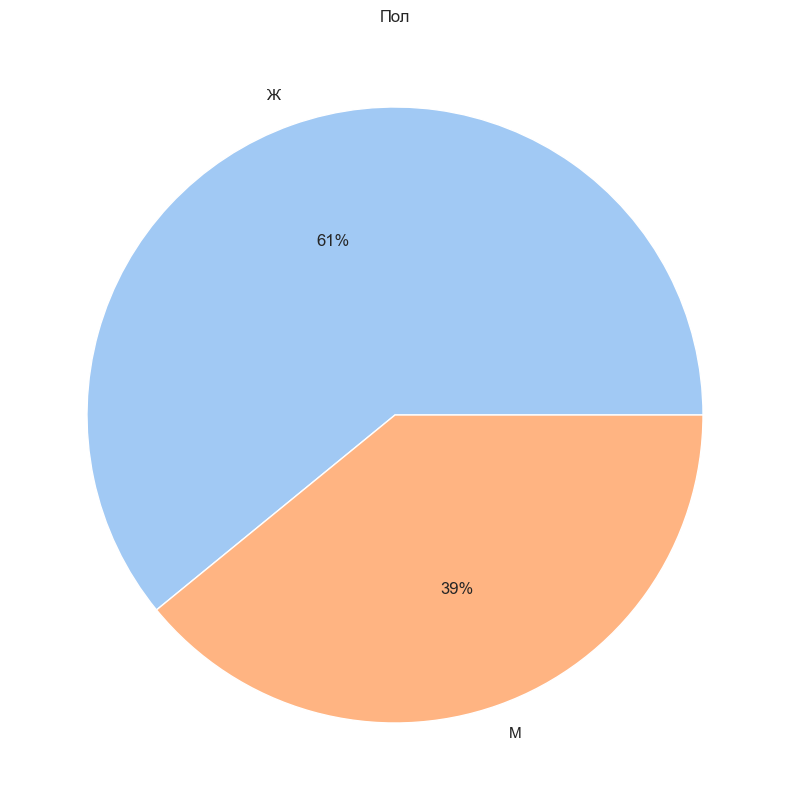

In [ ]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Пол'].unique())
dt = np.array([len(data[data['Пол'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Пол')
plt.show()

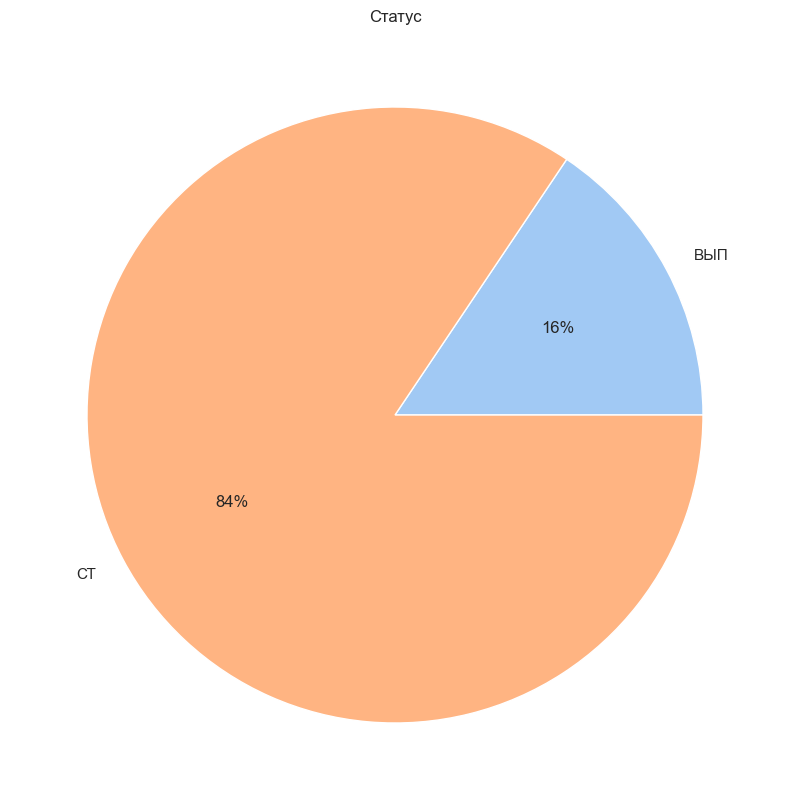

In [ ]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Статус'].unique())
dt = np.array([len(data[data['Статус'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Статус')
plt.show()

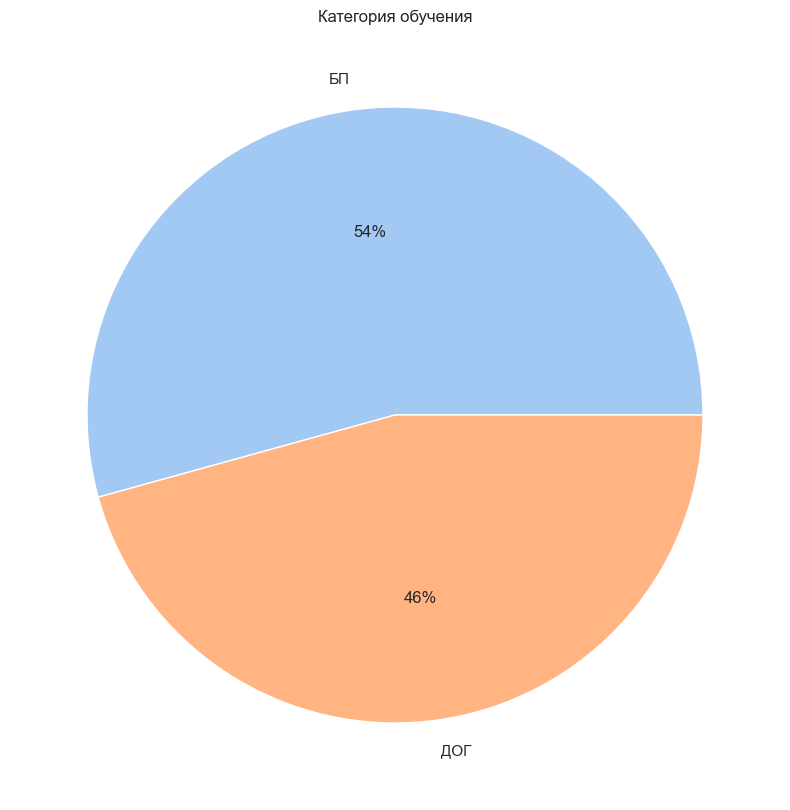

In [ ]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Категория обучения'].unique())
dt = np.array([len(data[data['Категория обучения'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Категория обучения')
plt.show()

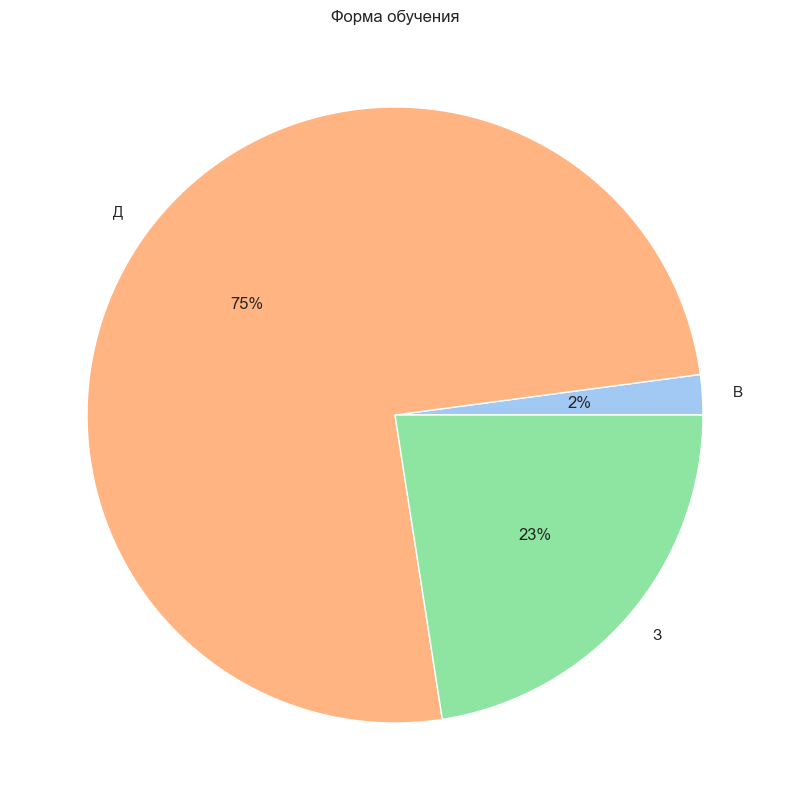

In [ ]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Форма обучения'].unique())
dt = np.array([len(data[data['Форма обучения'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Форма обучения')
plt.show()

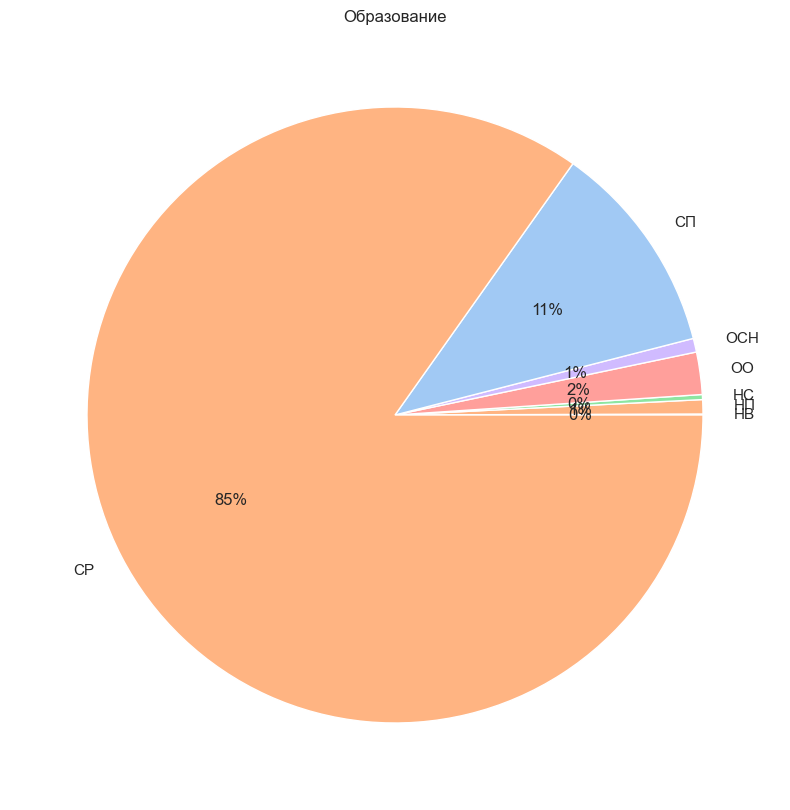

In [ ]:
sns.set(rc={'figure.figsize': (10, 10)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Образование'].unique())
dt = np.array([len(data[data['Образование'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Образование')
plt.show()

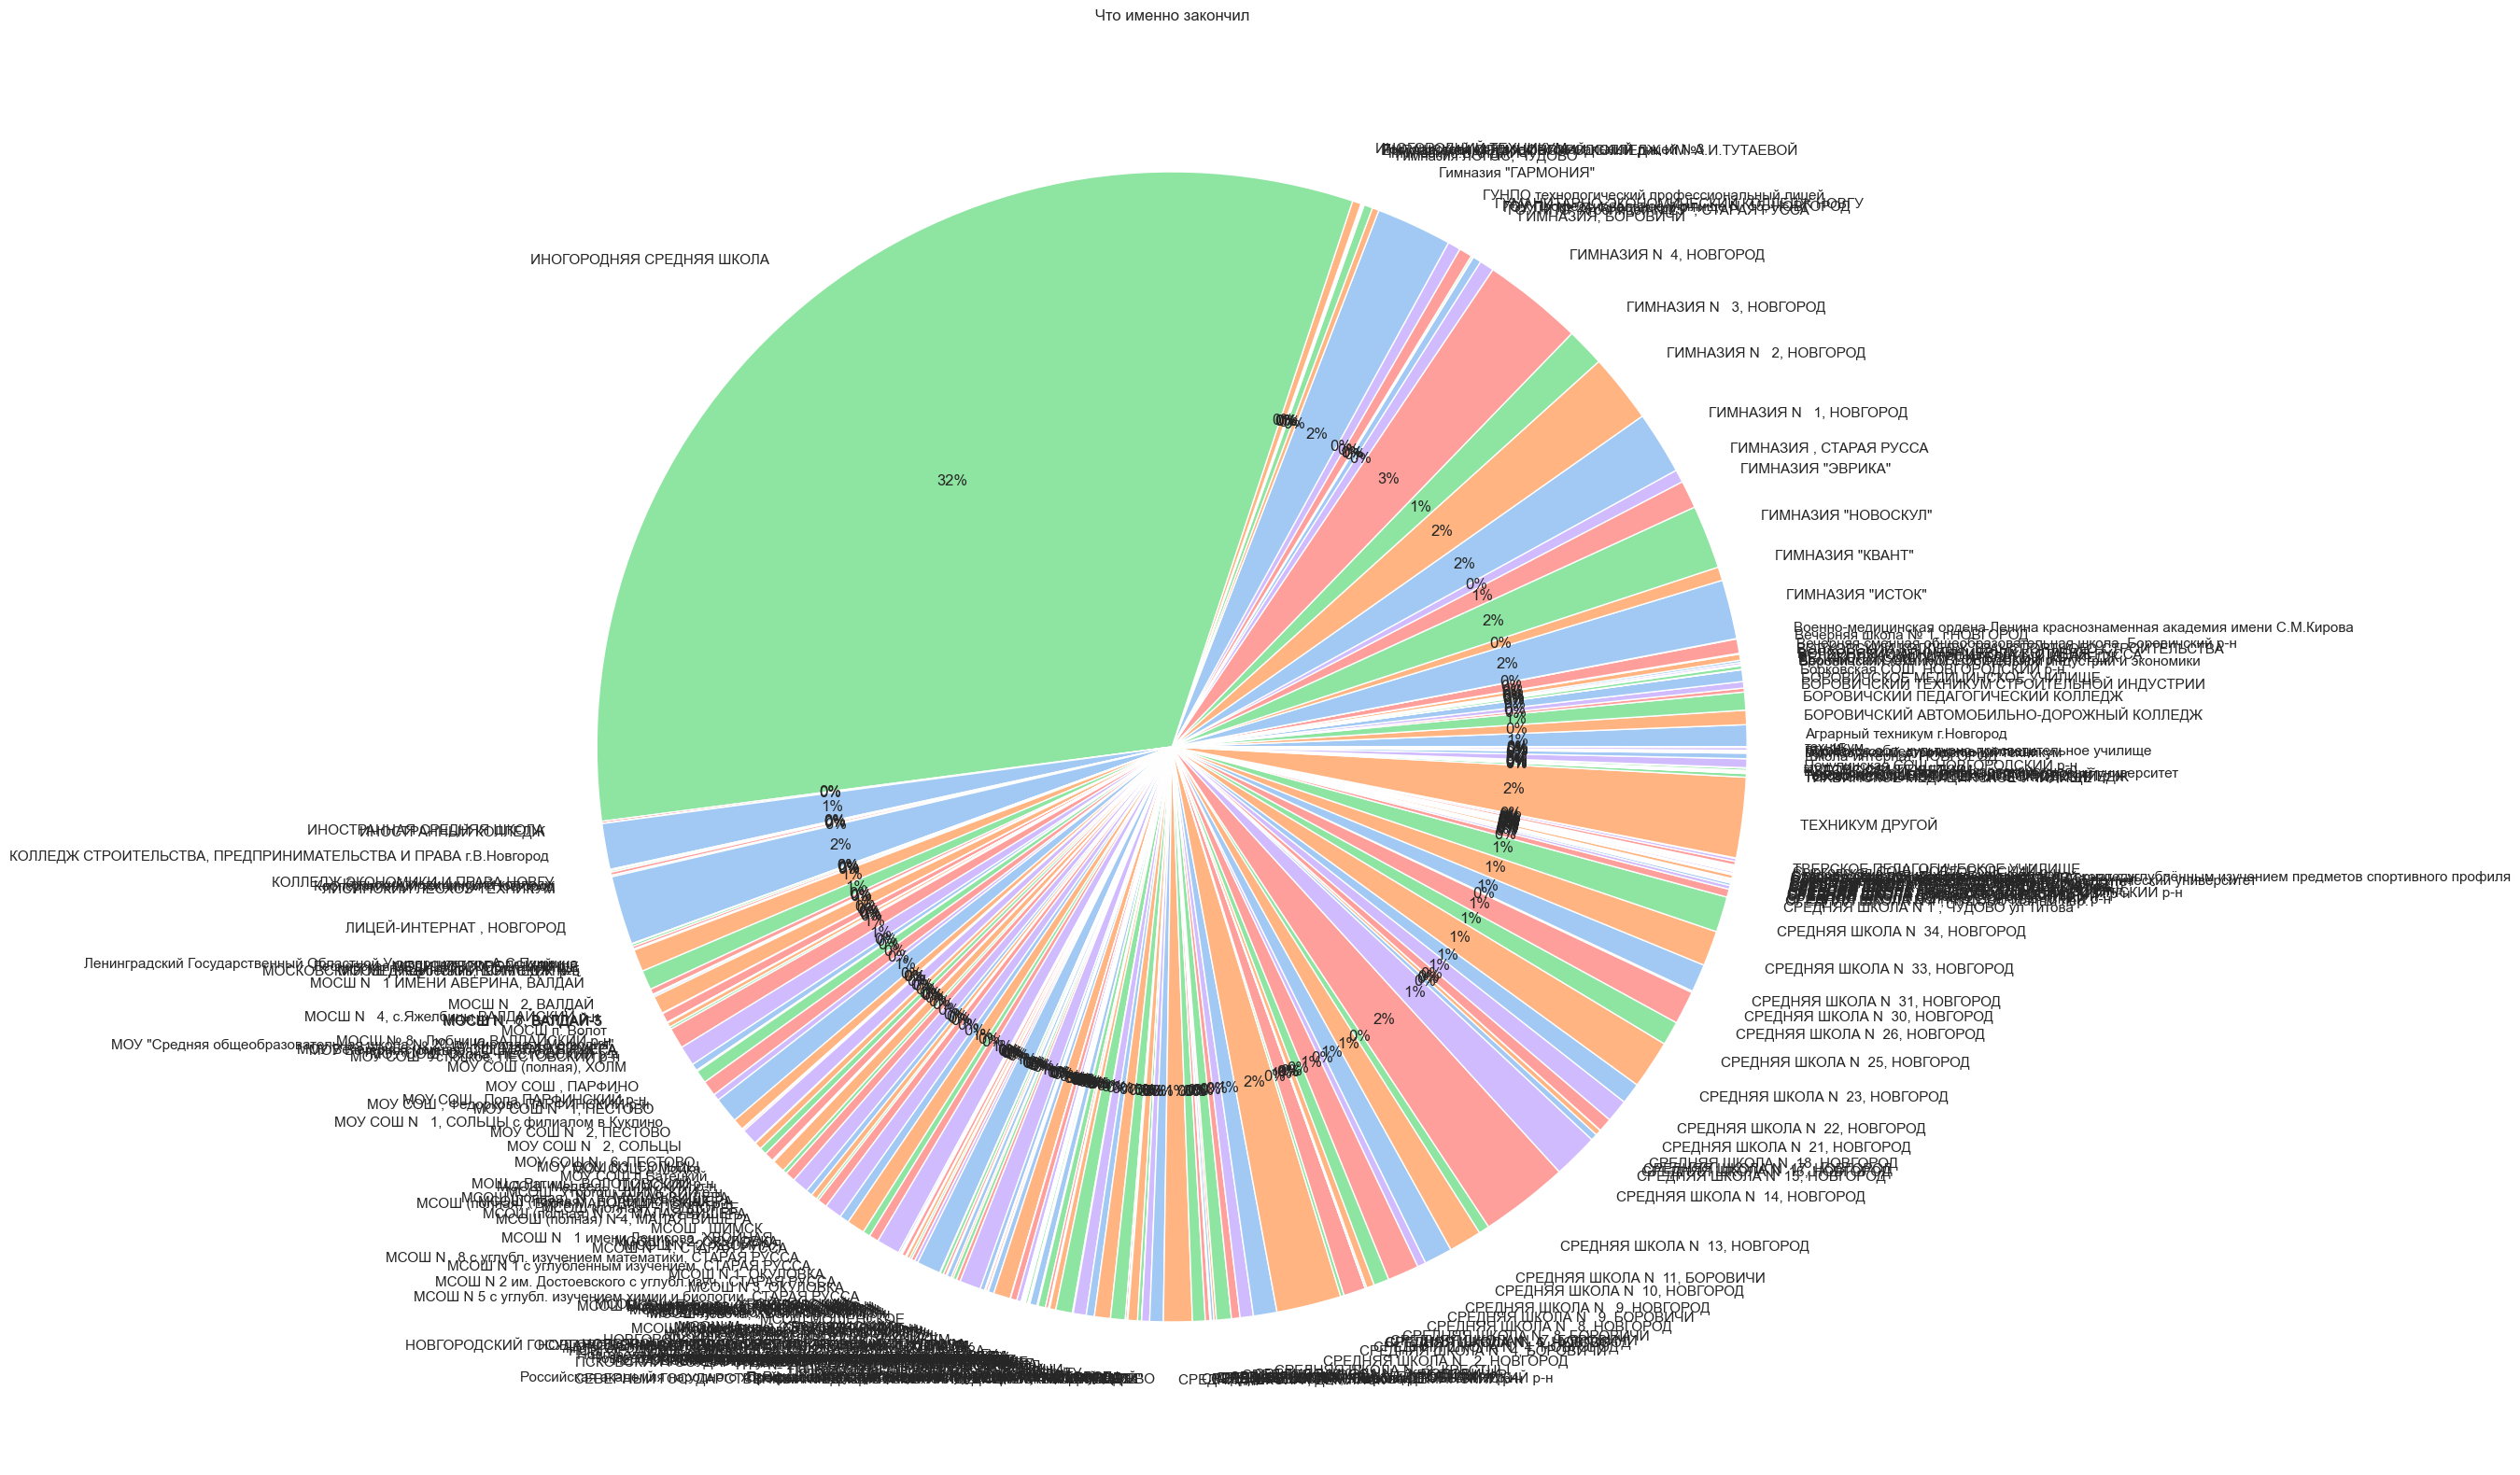

In [ ]:
sns.set(rc={'figure.figsize': (20, 20)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['Что именно закончил'].unique())
dt = np.array([len(data[data['Что именно закончил'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Что именно закончил')
plt.show()

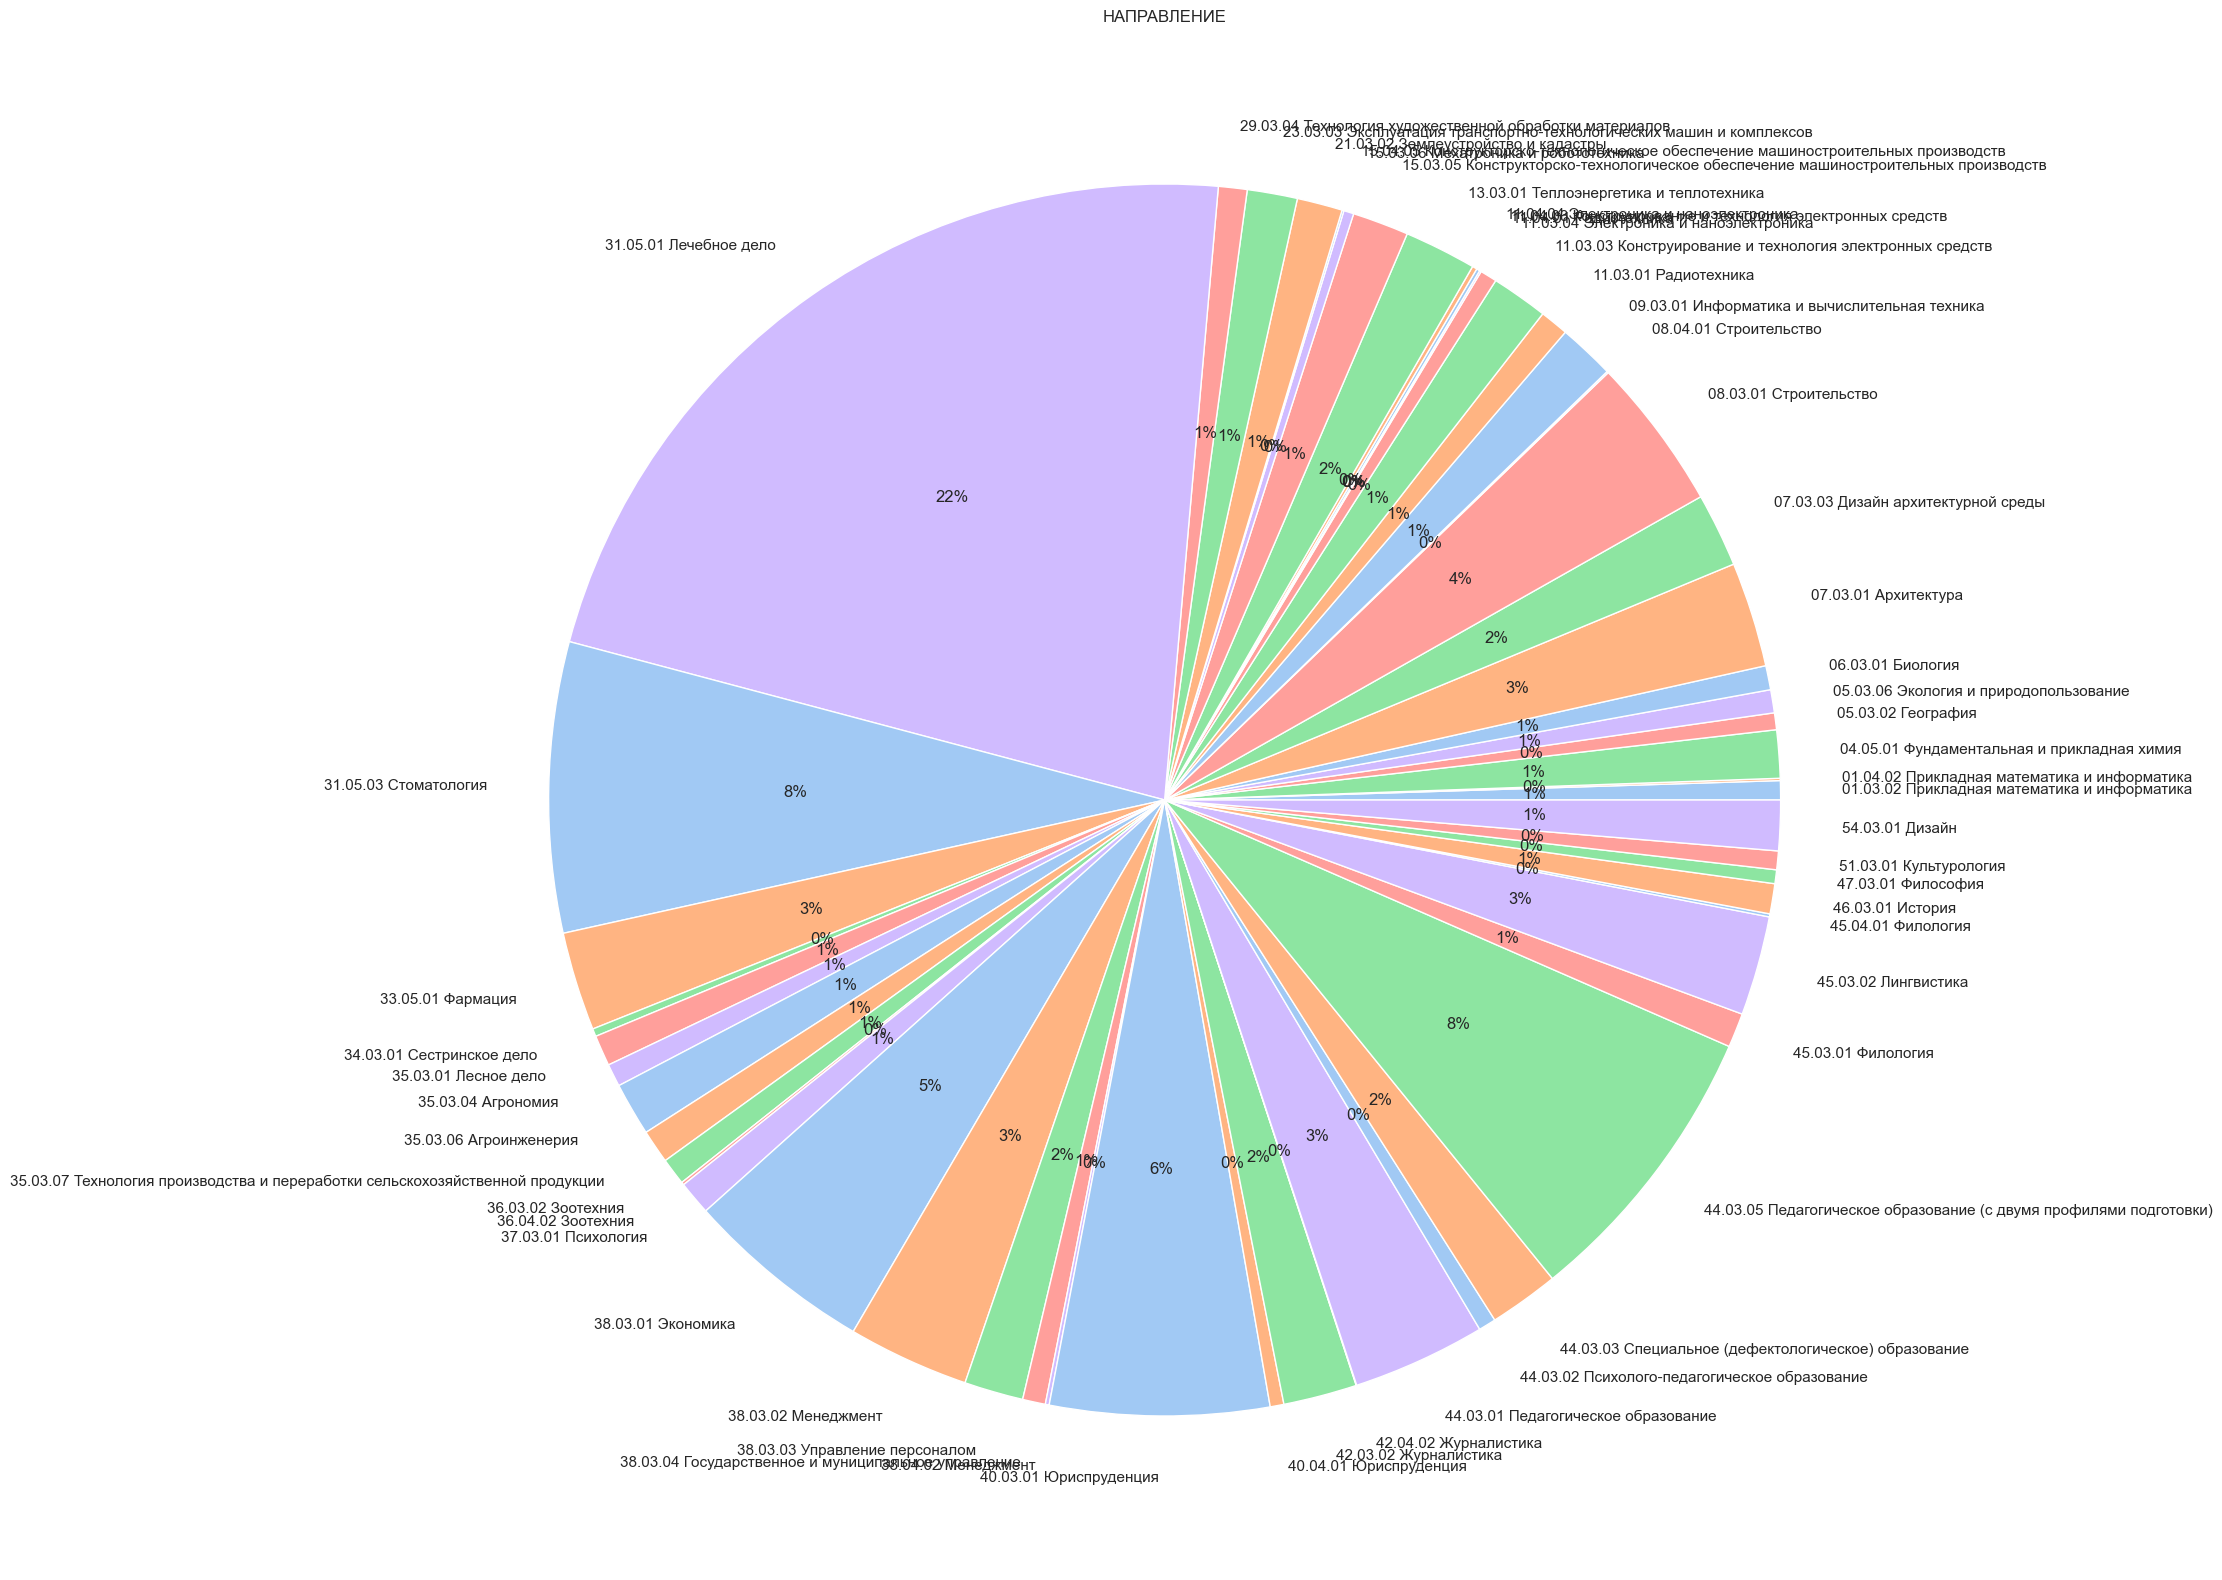

In [ ]:
sns.set(rc={'figure.figsize': (20, 20)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['НАПРАВЛЕНИЕ'].unique())
dt = np.array([len(data[data['НАПРАВЛЕНИЕ'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('НАПРАВЛЕНИЕ')
plt.show()

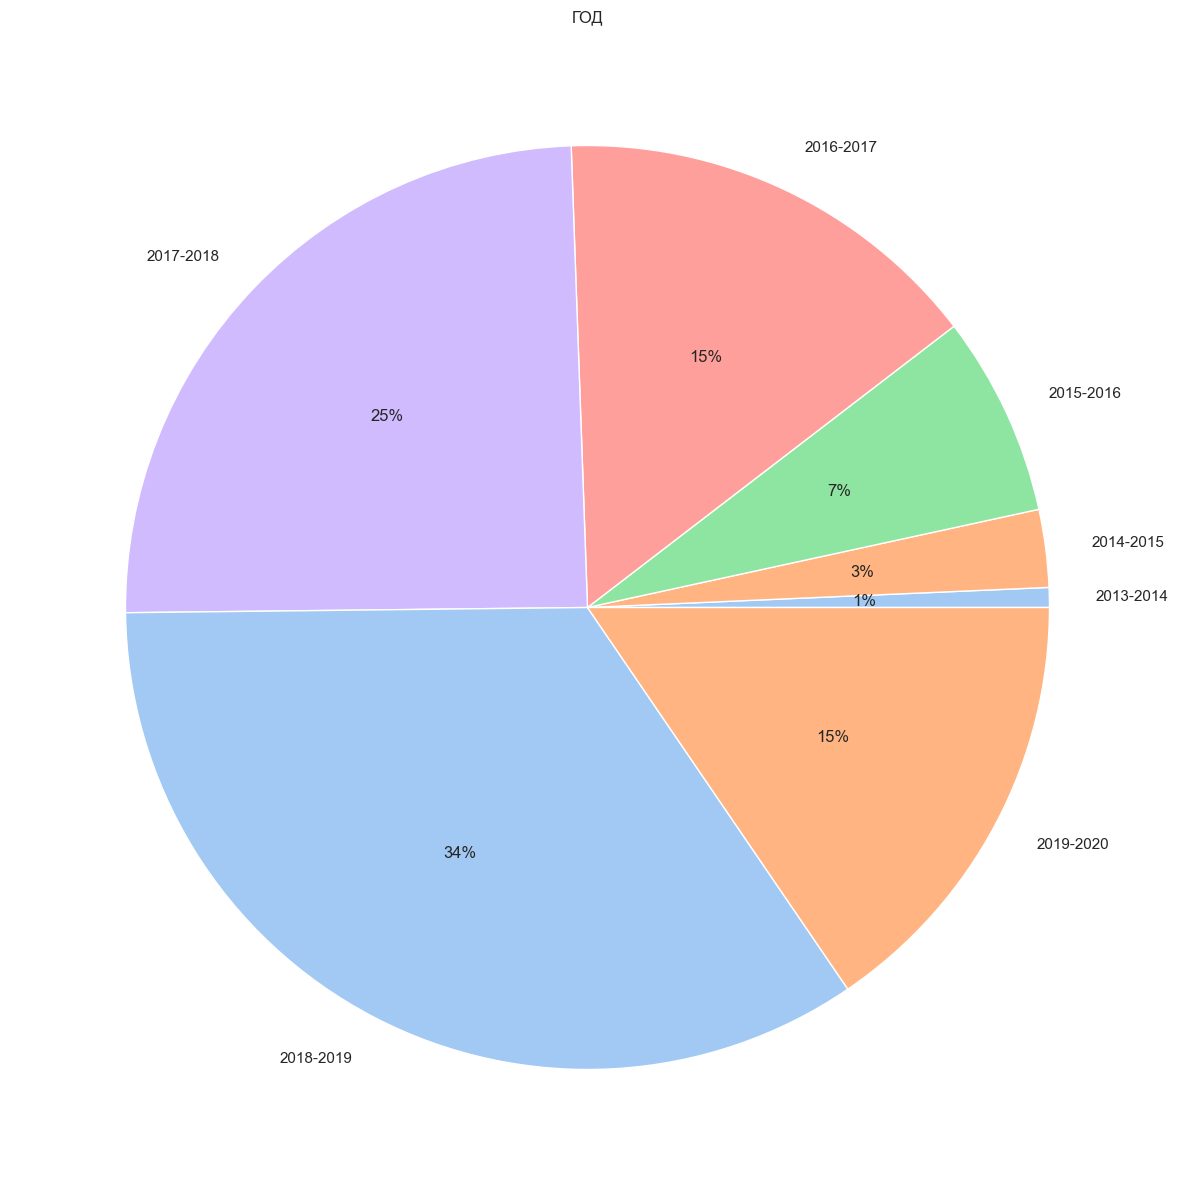

In [ ]:
sns.set(rc={'figure.figsize': (15, 15)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['ГОД'].unique())
dt = np.array([len(data[data['ГОД'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('ГОД')
plt.show()

Данный признак можно попробовать разделить на числовые, как год начала и окончания курса, либо оставить как категории

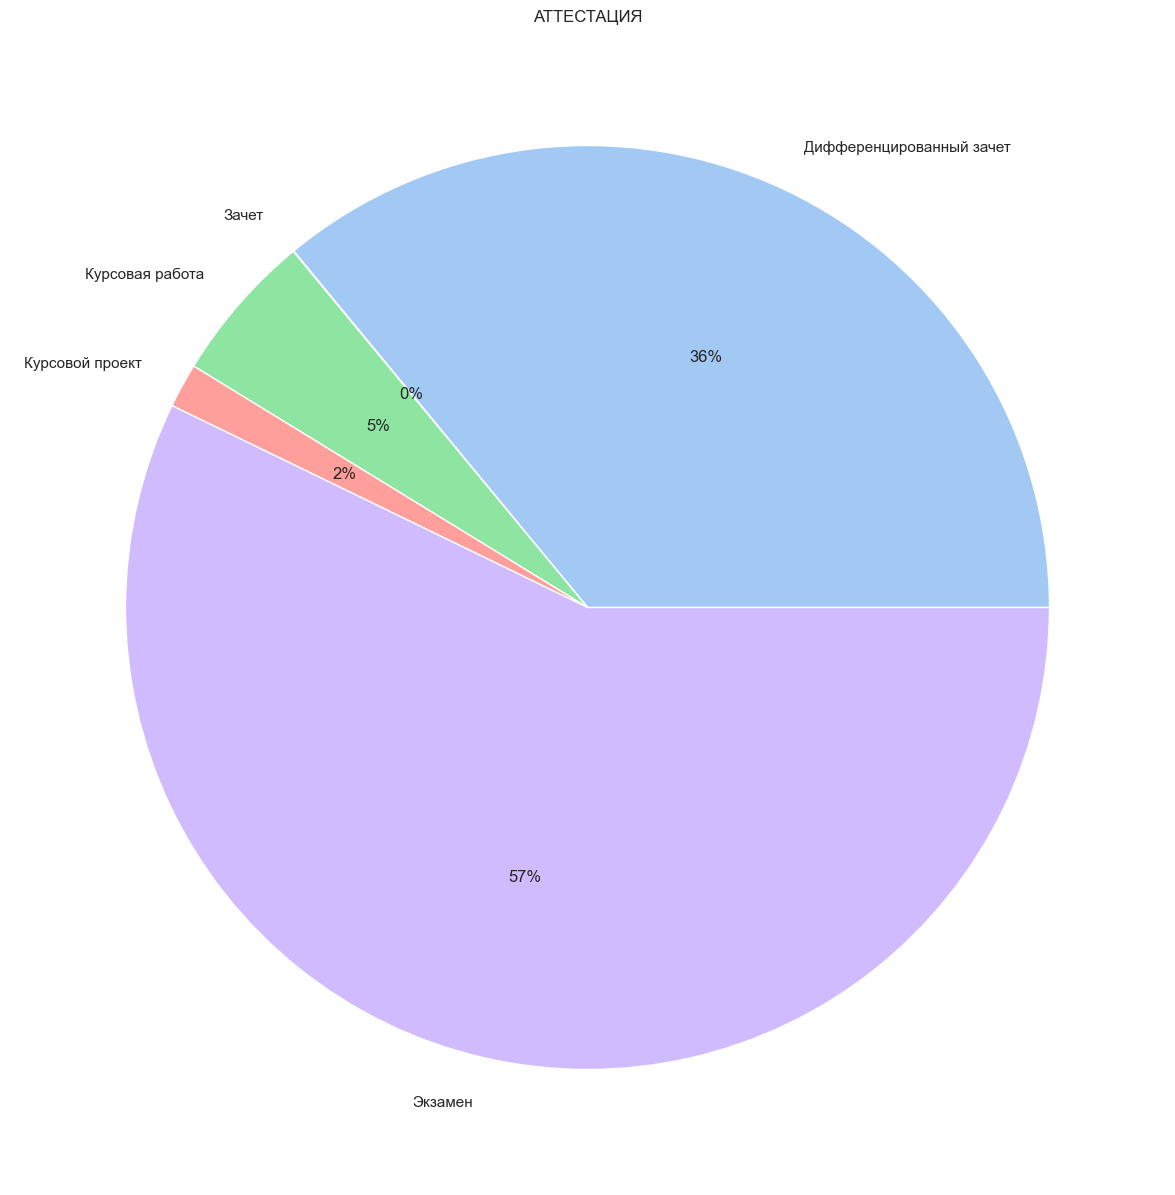

In [ ]:
sns.set(rc={'figure.figsize': (15, 15)})
colors = sns.color_palette('pastel')[0:5]
labels = sorted(data['АТТЕСТАЦИЯ'].unique())
dt = np.array([len(data[data['АТТЕСТАЦИЯ'] == i])for i in labels])
plt.pie(dt, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('АТТЕСТАЦИЯ')
plt.show()

In [ ]:
data['ДИСЦИПЛИНА'].value_counts()

ДИСЦИПЛИНА
История                                                                       3318
Философия                                                                     3248
Иностранный язык                                                              3165
Математика                                                                    2650
Физика                                                                        2003
                                                                              ... 
Иностранный язык в профессиональной деятельности                                 1
Коммуникационный менеджмент                                                      1
Социально-экономические проблемы сельских территорий                             1
Продвижение медиапроектов в интернете                                            1
Прогнозирование и стратегическое планирование в агропромышленном комплексе       1
Name: count, Length: 1400, dtype: int64

In [ ]:
data['ДИСЦИПЛИНА'].unique(), len(data['ДИСЦИПЛИНА'].unique())

(<StringArray>
 [                                                                              'Маркетинг',
  'Пропедевтика внутренних болезней, лучевая диагностика: пропедевтика внутренних болезней',
                                                                                    'Химия',
                                                                               'Статистика',
                                                                                'Педиатрия',
                                                                   'Теоретическая механика',
                                            'Основы архитектуры и строительных конструкций',
                                                                                  'История',
                                                                     'Технические культуры',
                             'Практика учебная : уход за больными терапевтического профиля',
  ...
                                      'Особенност

In [ ]:
data['STD_ID'].value_counts()

STD_ID
113096    61
114310    59
114302    59
114300    59
142781    58
          ..
200986     1
199431     1
162272     1
200391     1
194047     1
Name: count, Length: 5084, dtype: int64

студенты повторяются значит их можно оставить как ещё один котегориальный признак

## Посмотрим как признаки влияют друг на друга

In [ ]:
for elem in data.columns:
    if data[elem].to_numpy().dtype == object:
        print(data[elem].to_numpy().dtype)

object
object
object
object
object
object
object
object
object
object


100%|██████████| 15/15 [00:00<00:00, 210.97it/s]


<Axes: >

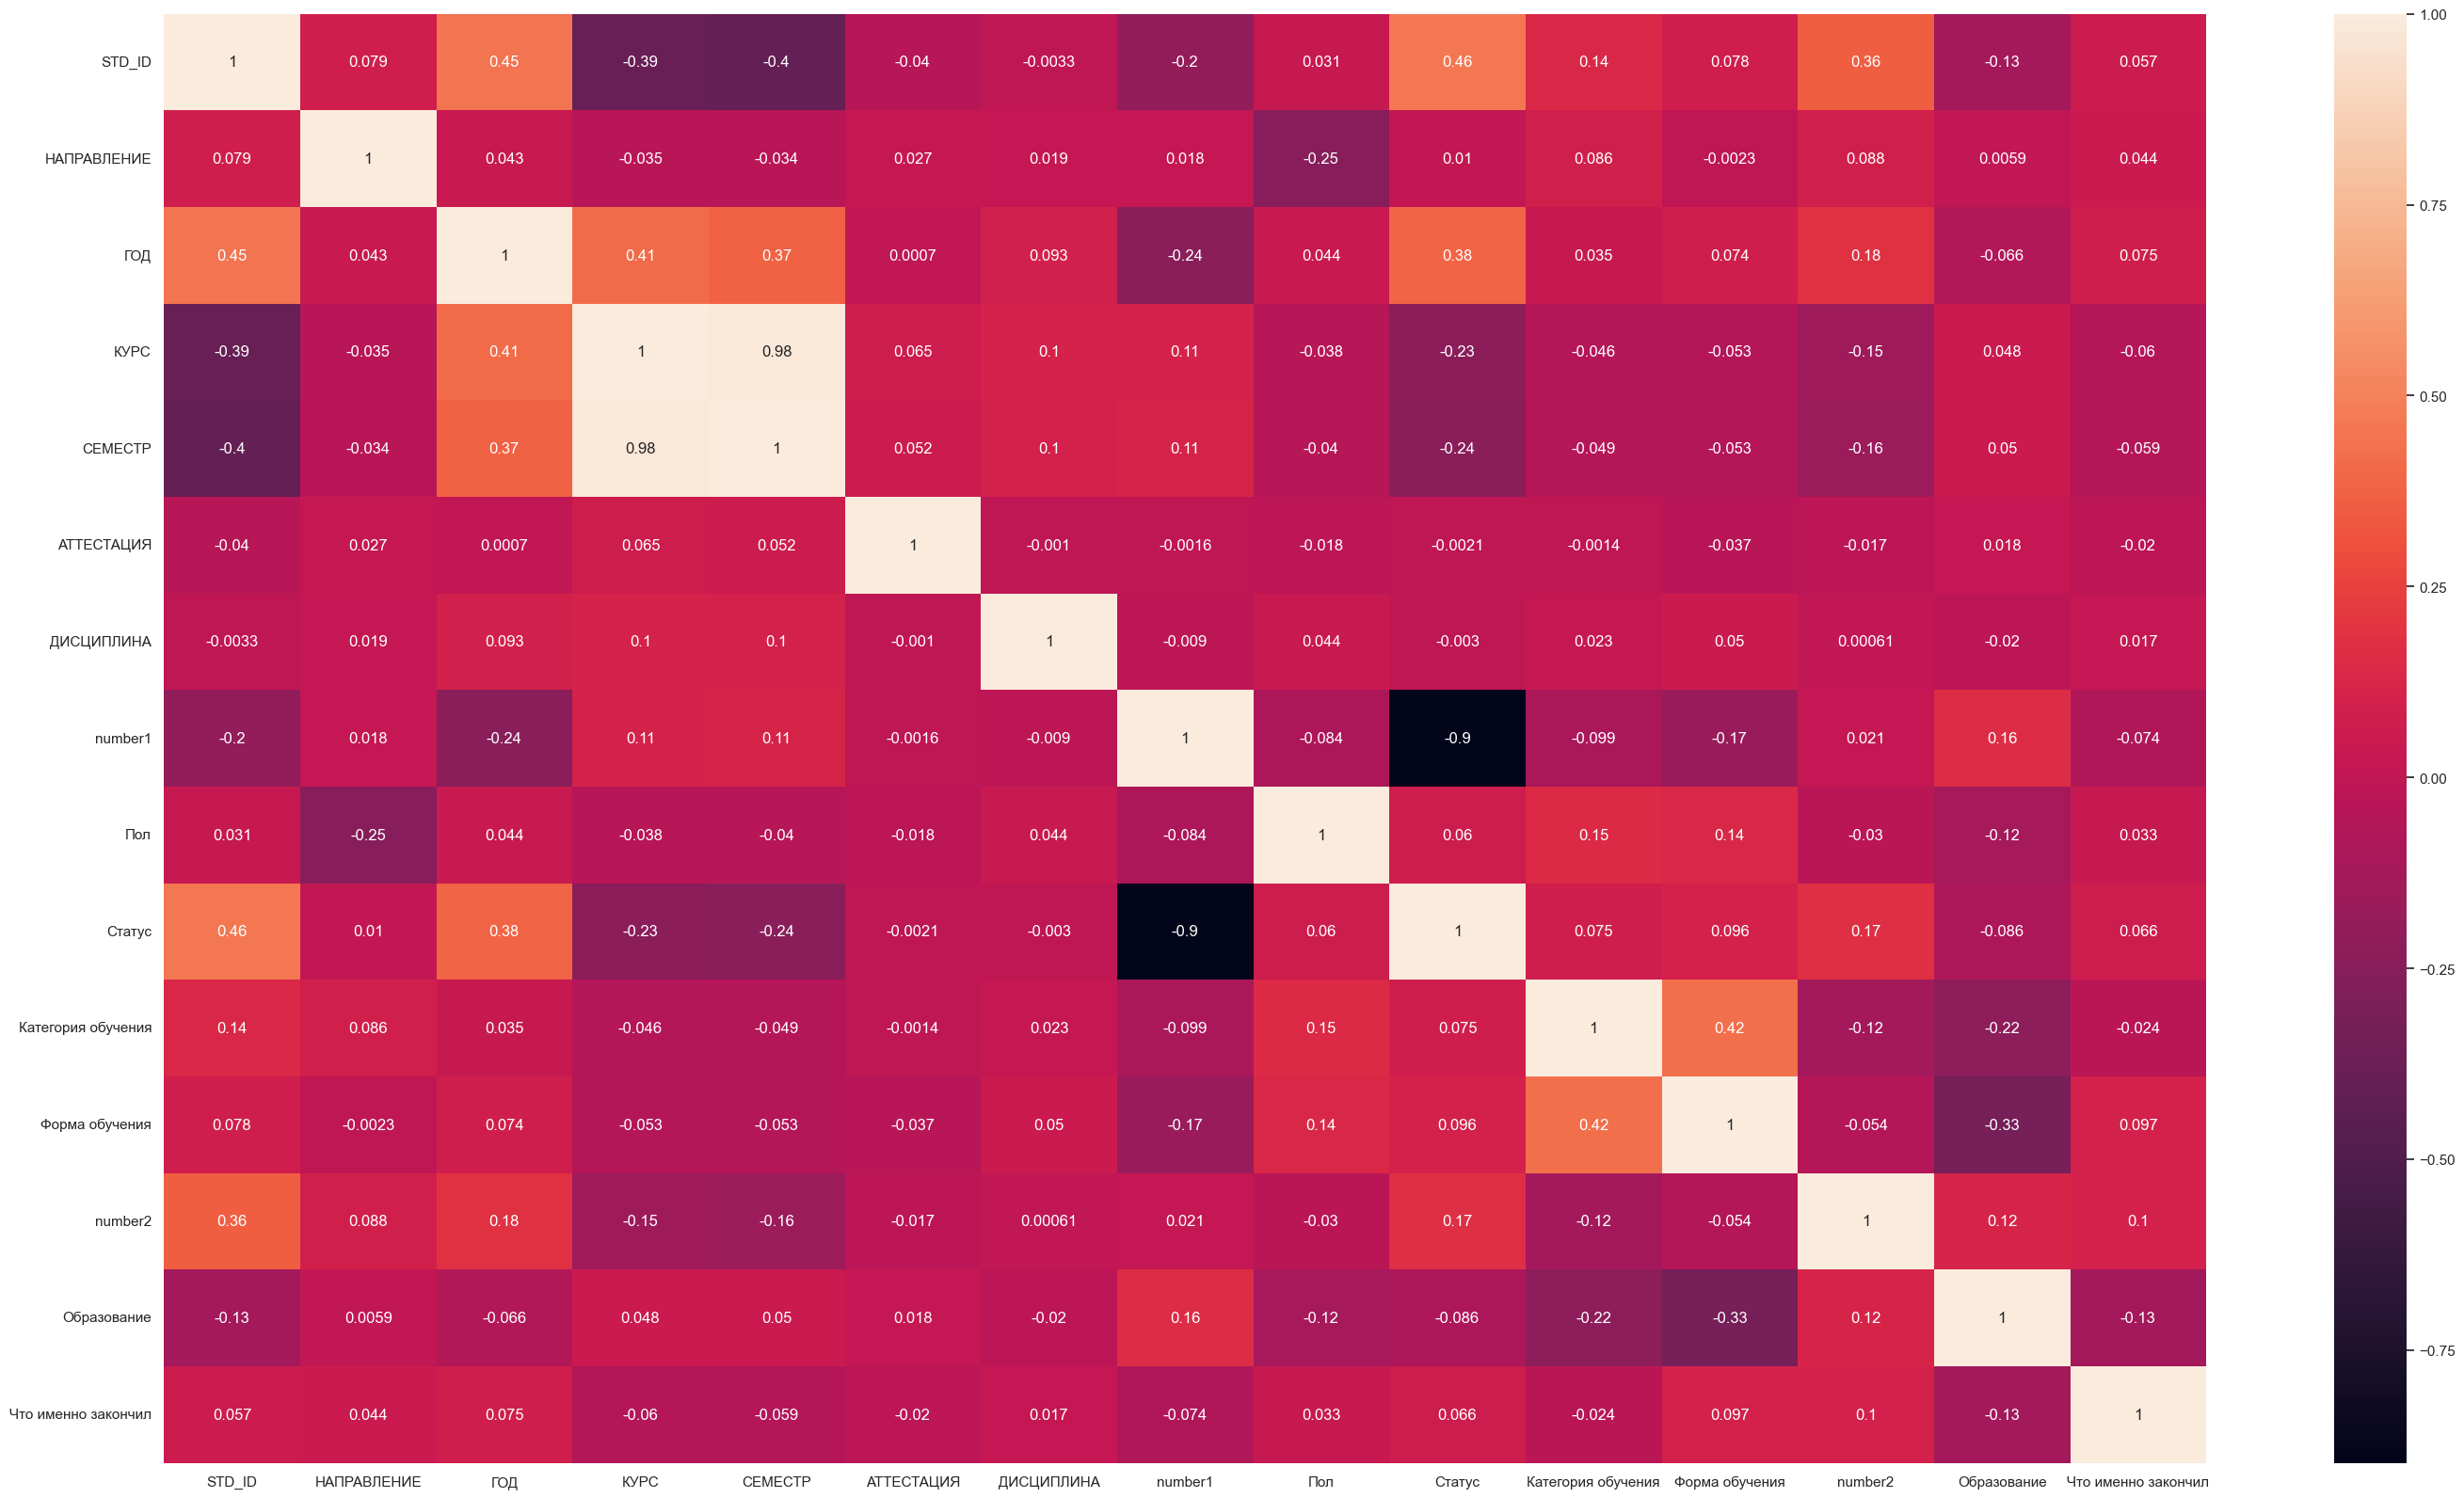

In [ ]:
corr_data = data.copy()

for elem in tqdm(data.columns):
    if data[elem].to_numpy().dtype == object:
        corr_data[elem] = corr_data[elem].astype('category')
        corr_data[elem] = corr_data[elem].cat.codes

sns.set(rc={'figure.figsize': (35, 20)})

sns.heatmap(corr_data.corr(), annot=True)

In [ ]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг,3989.0,М,СТ,БП,Д,5445.0,СР,"СРЕДНЯЯ ШКОЛА N 31, НОВГОРОД"
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг...",14025.0,Ж,ВЫП,ДОГ,Д,2668.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия,7212.0,Ж,СТ,БП,Д,11431.0,СР,"ГИМНАЗИЯ N 2, НОВГОРОД"
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика,3293.0,М,СТ,БП,Д,4981.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия,875.0,Ж,СТ,ДОГ,Д,2034.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право,861.0,Ж,СТ,ДОГ,В,8613.0,СР,"МОУ СОШ N 1, СОЛЬЦЫ с филиалом в Куклино"
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология,3859.0,Ж,СТ,ДОГ,Д,5505.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык,6989.0,Ж,СТ,БП,Д,4900.0,СР,"ГИМНАЗИЯ N 1, НОВГОРОД"
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика,4091.0,Ж,СТ,ДОГ,З,5466.0,СР,"Гимназия ""ГАРМОНИЯ"""


# Выбор алгоритма

In [ ]:
X = data.copy()
for elem in tqdm(X.columns):
    if X[elem].to_numpy().dtype == object:
        X[elem] = X[elem].astype('category')
        X[elem] = X[elem].cat.codes

Y = pd.read_csv('./onti-students-performance/y_train.csv')['mark']
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.1, random_state=42)

100%|██████████| 15/15 [00:00<00:00, 298.47it/s]


## LinearRegression

In [ ]:
model_LR = LinearRegression()

model_LR.fit(X_train, Y_train)

pred_model_LR = [5 if i > 5 else abs(i) for i in model_LR.predict(X_valid)]

## SGDRegressor

In [ ]:
model_SGDR = SGDRegressor()

model_SGDR.fit(X_train, Y_train)

pred_model_SGDR = [5 if i > 5 else abs(i) for i in model_SGDR.predict(X_valid)]

## GradientBoostingRegressor

In [ ]:
model_GBR = GradientBoostingRegressor()

model_GBR.fit(X_train, Y_train)

pred_model_GBR = [5 if i > 5 else abs(i) for i in model_GBR.predict(X_valid)]

## RandomForestRegressor

In [ ]:
model_RFR = RandomForestRegressor(random_state=42)

model_RFR.fit(X_train, Y_train)

pred_model_RFR = [5 if i > 5 else abs(i) for i in model_RFR.predict(X_valid)]

## MLPRegressor

In [ ]:
model_MLPR = MLPRegressor()

model_MLPR.fit(X_train, Y_train)

pred_model_MLPR = [5 if i > 5 else abs(i) for i in model_MLPR.predict(X_valid)]

## Посмотрим на результаты

In [ ]:
comparison_table = pd.DataFrame(result_table([pred_model_LR,
                                              pred_model_SGDR,
                                              pred_model_GBR,
                                              pred_model_RFR,
                                              pred_model_MLPR
                                             ],
                                              Y_valid,
                                              subcol='models',
                                              valueSubCol=['LR', 'SGDR', 'GBR', 'RFR', 'MLPR']))
comparison_table

,models,mean_squared_error,mean_absolute_error,median_absolute_error,mean_absolute_percentage_error,r2_score
0,LR,0.688030,0.586205,0.548719,0.149806,0.170130
1,SGDR,1.108823,0.811822,1.000000,0.237761,-1.155358
2,GBR,0.652375,0.556739,0.515184,0.142171,0.253913
3,RFR,0.556258,0.441972,0.370000,0.112102,0.457565
4,MLPR,1.108823,0.811822,1.000000,0.237761,-1.155358


In [ ]:
comparison_table[comparison_table['r2_score'] == comparison_table['r2_score'].max()]

,models,mean_squared_error,mean_absolute_error,median_absolute_error,mean_absolute_percentage_error,r2_score
3,RFR,0.556258,0.441972,0.37,0.112102,0.457565


In [ ]:
sorted(comparison_table['r2_score'])

[-1.1553580729225605,
 -1.1553580729225605,
 0.17012951311354896,
 0.2539128153243191,
 0.45756460296844004]

# Подберем параметры для лучшей модели

In [ ]:
model_GBR = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42,
    loss='squared_error'
)

In [ ]:
model_GBR.fit(X_train, Y_train)

pred_model_GBR = [5 if i > 5 else abs(i) for i in model_GBR.predict(X_valid)]

In [ ]:
result_pred(pred_model_GBR, Y_valid)

mean_squared_error: 0.5768801289701951
mean_absolute_error: 0.4822898249791058
median_absolute_error: 0.4365459898609596
mean_absolute_percentage_error: 0.12275175476159382
r2_score: 0.41660013179309985


# Предскажем тест

In [ ]:
testData = pd.read_csv('./onti-students-performance/X_test.csv').drop(columns=['Unnamed: 0'])

In [ ]:
testData

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА
0,163261,35.03.04 Агрономия,2018-2019,3.0,5.0,Дифференцированный зачет,История
1,162990,23.03.03 Эксплуатация транспортно-технологичес...,2019-2020,4.0,7.0,Экзамен,Сертификация и лицензирование в сфере производ...
2,192595,40.03.01 Юриспруденция,2018-2019,1.0,2.0,Экзамен,История государства и права России
3,198675,38.03.01 Экономика,2018-2019,2.0,3.0,Дифференцированный зачет,Иностранный язык в сфере профессиональной комм...
4,162111,44.03.05 Педагогическое образование (с двумя п...,2018-2019,3.0,6.0,Экзамен,Физическая химия
...,...,...,...,...,...,...,...
26260,164804,31.05.01 Лечебное дело,2019-2020,4.0,7.0,Экзамен,"Факультетская хирургия, урология"
26261,170508,40.03.01 Юриспруденция,2019-2020,4.0,7.0,Дифференцированный зачет,Арбитражный процесс
26262,178316,31.05.03 Стоматология,2017-2018,1.0,2.0,Экзамен,"Гистология, эмбриология, цитология - гистологи..."
26263,186542,46.03.01 История,2019-2020,2.0,3.0,Дифференцированный зачет,Иностранный язык


In [ ]:
testData = testData.merge(studs_info, how='left', on='STD_ID').dropna()

for elem in testData.columns:
    if testData[elem].to_numpy().dtype == object:
        testData[elem] = testData[elem].astype('category')
        testData[elem] = testData[elem].cat.codes

In [ ]:
testData.isnull().sum()

STD_ID                 0
НАПРАВЛЕНИЕ            0
ГОД                    0
КУРС                   0
СЕМЕСТР                0
АТТЕСТАЦИЯ             0
ДИСЦИПЛИНА             0
number1                0
Пол                    0
Статус                 0
Категория обучения     0
Форма обучения         0
number2                0
Образование            0
Что именно закончил    0
dtype: int64

In [ ]:
Y_predTest = [5 if i > 5 else abs(i) for i in model_GBR.predict(testData)]

In [ ]:
submission = pd.read_csv('./onti-students-performance/sample_submission.csv')

In [ ]:
submission['mark'] = Y_predTest

In [ ]:
submission.to_csv('sub.csv', index=False)

In [ ]:
pd.read_csv('sub.csv')

,index,mark
0,56065,4.106184
1,304637,4.460165
2,177437,3.829629
3,222396,3.781247
4,271996,4.466693
...,...,...
26260,49838,4.625579
26261,273753,3.639689
26262,35426,3.719542
26263,160476,4.064676
